# EURNOK V. EURSEK

### GOOGLE DRIVE

In [1]:
from google.colab import drive
import sys, os, shutil, subprocess

drive.mount('/content/drive')

REPO_ROOT  = '/content/stk-mat2011'
REPO_DATA  = f'{REPO_ROOT}/code/data/processed'
DRIVE_DATA = '/content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/data/processed'

# 1. Clone (or pull if already cloned this session)
if not os.path.isdir(REPO_ROOT):
    subprocess.run(['git', 'clone', 'https://github.com/egil10/stk-mat2011.git', REPO_ROOT], check=True)
else:
    subprocess.run(['git', '-C', REPO_ROOT, 'pull'], check=True)

# 2. Replace empty data dir from clone with symlink to Drive
if os.path.isdir(REPO_DATA) and not os.path.islink(REPO_DATA):
    shutil.rmtree(REPO_DATA)
if os.path.islink(REPO_DATA) and not os.path.exists(REPO_DATA):
    os.unlink(REPO_DATA)  # broken symlink
if not os.path.islink(REPO_DATA):
    os.symlink(DRIVE_DATA, REPO_DATA)

# 3. Set up imports + working directory to match local notebook environment
sys.path.append(f'{REPO_ROOT}/code/scripts')
os.chdir(f'{REPO_ROOT}/code/notebooks')   # ← key change: mimics local CWD

# 4. Sanity check
print(f"CWD:           {os.getcwd()}")
print(f"wfo.py:        {os.path.isfile(f'{REPO_ROOT}/code/scripts/wfo.py')}")
print(f"Data symlink:  {os.path.islink(REPO_DATA)} → {os.readlink(REPO_DATA) if os.path.islink(REPO_DATA) else 'N/A'}")
print(f"Parquet count: {len([f for f in os.listdir(REPO_DATA) if f.endswith('.parquet')])}")
print(f"Path test:     {os.path.exists('../data/processed/audusd_dukascopy_ask_202401.parquet')}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CWD:           /content/stk-mat2011/code/notebooks
wfo.py:        True
Data symlink:  True → /content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/data/processed
Parquet count: 916
Path test:     True


### IMPORT

In [2]:
%%capture
!pip install arch optuna

import os, sys, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from arch import arch_model

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", module="statsmodels.tsa.base.tsa_model")

# scripts already on sys.path from Cell 2 — but keep this for parity with local notebook
sys.path.append(os.path.abspath('../scripts'))

from spread import SPREAD
from screener import SCREENER
from engine import ENGINE
from backtester import BACKTESTER
from tearsheet import TEARSHEET
from descriptive import DESCRIPTIVE
from wfo import WFO

### PARAMS

In [3]:
# ==========================================
# 1. CORE ASSET CONFIG (NOK/SEK)
# ==========================================
NAME_A, NAME_B = "EURNOK", "EURSEK"
START_HOUR = 0
END_HOUR = 24
BAR_THRESHOLD = 1000      # Tick-aggregation volume threshold

# EDA & Screener Defaults
EDA_THRESHOLD = 1000
EDA_START_HOUR = 0
EDA_END_HOUR = 24
ROLLING_WINDOW = 2000
ROLLING_STEP = 200

# ==========================================
# 2. ADAPTIVE MATH (ENGINE)
# ==========================================
TRAIN_DAYS = 30           # Daily rolling training history
COINT_WINDOW = 300        # Capture microstructure cointegration
Z_WINDOW = 100            # Mean-reversion lookback window
THRESHOLD = 1000

# HMM Architecture (Locked via Synthetic Diagnostics)
K_REGIMES = 2
WINSORIZE_STD = 4.0       # Stabilizes solver against high Scandinavian kurtosis
SCALING = 10000           # Standard portfolio-wide scaling

# ==========================================
# 3. ADAPTIVE RULES (WFO MANAGER)
# ==========================================
# WFO is critical here to see if the pair EVER regains mean-reversion.
VAL_MONTHS = 3            # Look back 3 months to find optimal execution
TEST_MONTHS = 1           # Apply optimized rules to the next 1 month
N_TRIALS = 100            # Trials per month

In [4]:
# Plot export config
PAIR_NAME = f"{NAME_A}_{NAME_B}"
SAVE_PLOTS_PDF = True
PLOT_OUTDIR = os.path.join(os.path.dirname(os.path.dirname(DRIVE_DATA)), "plots", PAIR_NAME)
os.makedirs(PLOT_OUTDIR, exist_ok=True)
print(f"Plot PDFs will be saved to: {PLOT_OUTDIR}")

Plot PDFs will be saved to: /content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/plots/EURNOK_EURSEK


In [5]:
DATA_DIR = "../data/processed"

def make_files(name_a, name_b, months):
    """Build the [ask_a, bid_a, ask_b, bid_b] file list for a pair across given months."""
    a, b = name_a.lower(), name_b.lower()
    return [
        [f"{DATA_DIR}/{a}_dukascopy_ask_{m}.parquet" for m in months],
        [f"{DATA_DIR}/{a}_dukascopy_bid_{m}.parquet" for m in months],
        [f"{DATA_DIR}/{b}_dukascopy_ask_{m}.parquet" for m in months],
        [f"{DATA_DIR}/{b}_dukascopy_bid_{m}.parquet" for m in months],
    ]

### EDA

built 16028 rows

  DATASET OVERVIEW
Pair:              EURNOK  vs  EURSEK
Bars:              16,028
Period:            2024-01-02 00:10:12.416000+00:00  →  2024-02-29 23:59:57.446000+00:00
Calendar span:     58 days
Trading days:      43
Bars per day:      372.7 (avg)
Hours covered:     [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23)]

  LIQUIDITY PROFILE
Median spread:           A=1.78  B=1.33  bps
P95 spread (tail cost):  A=5.72  B=4.40  bps
Tightest 4h window:      09:00 → 12:00 UTC
Widest   4h window:      20:00 → 23:00 UTC
Round-trip cost (median total): 3.08 bps

  RETURN STATISTICS
        Mean (bps)  Vol (bps)      Skew      Kurt  P5 (bps)  P95 (bps)  Min (bps)  Max (bps)
EURNOK       0.013      2.787   

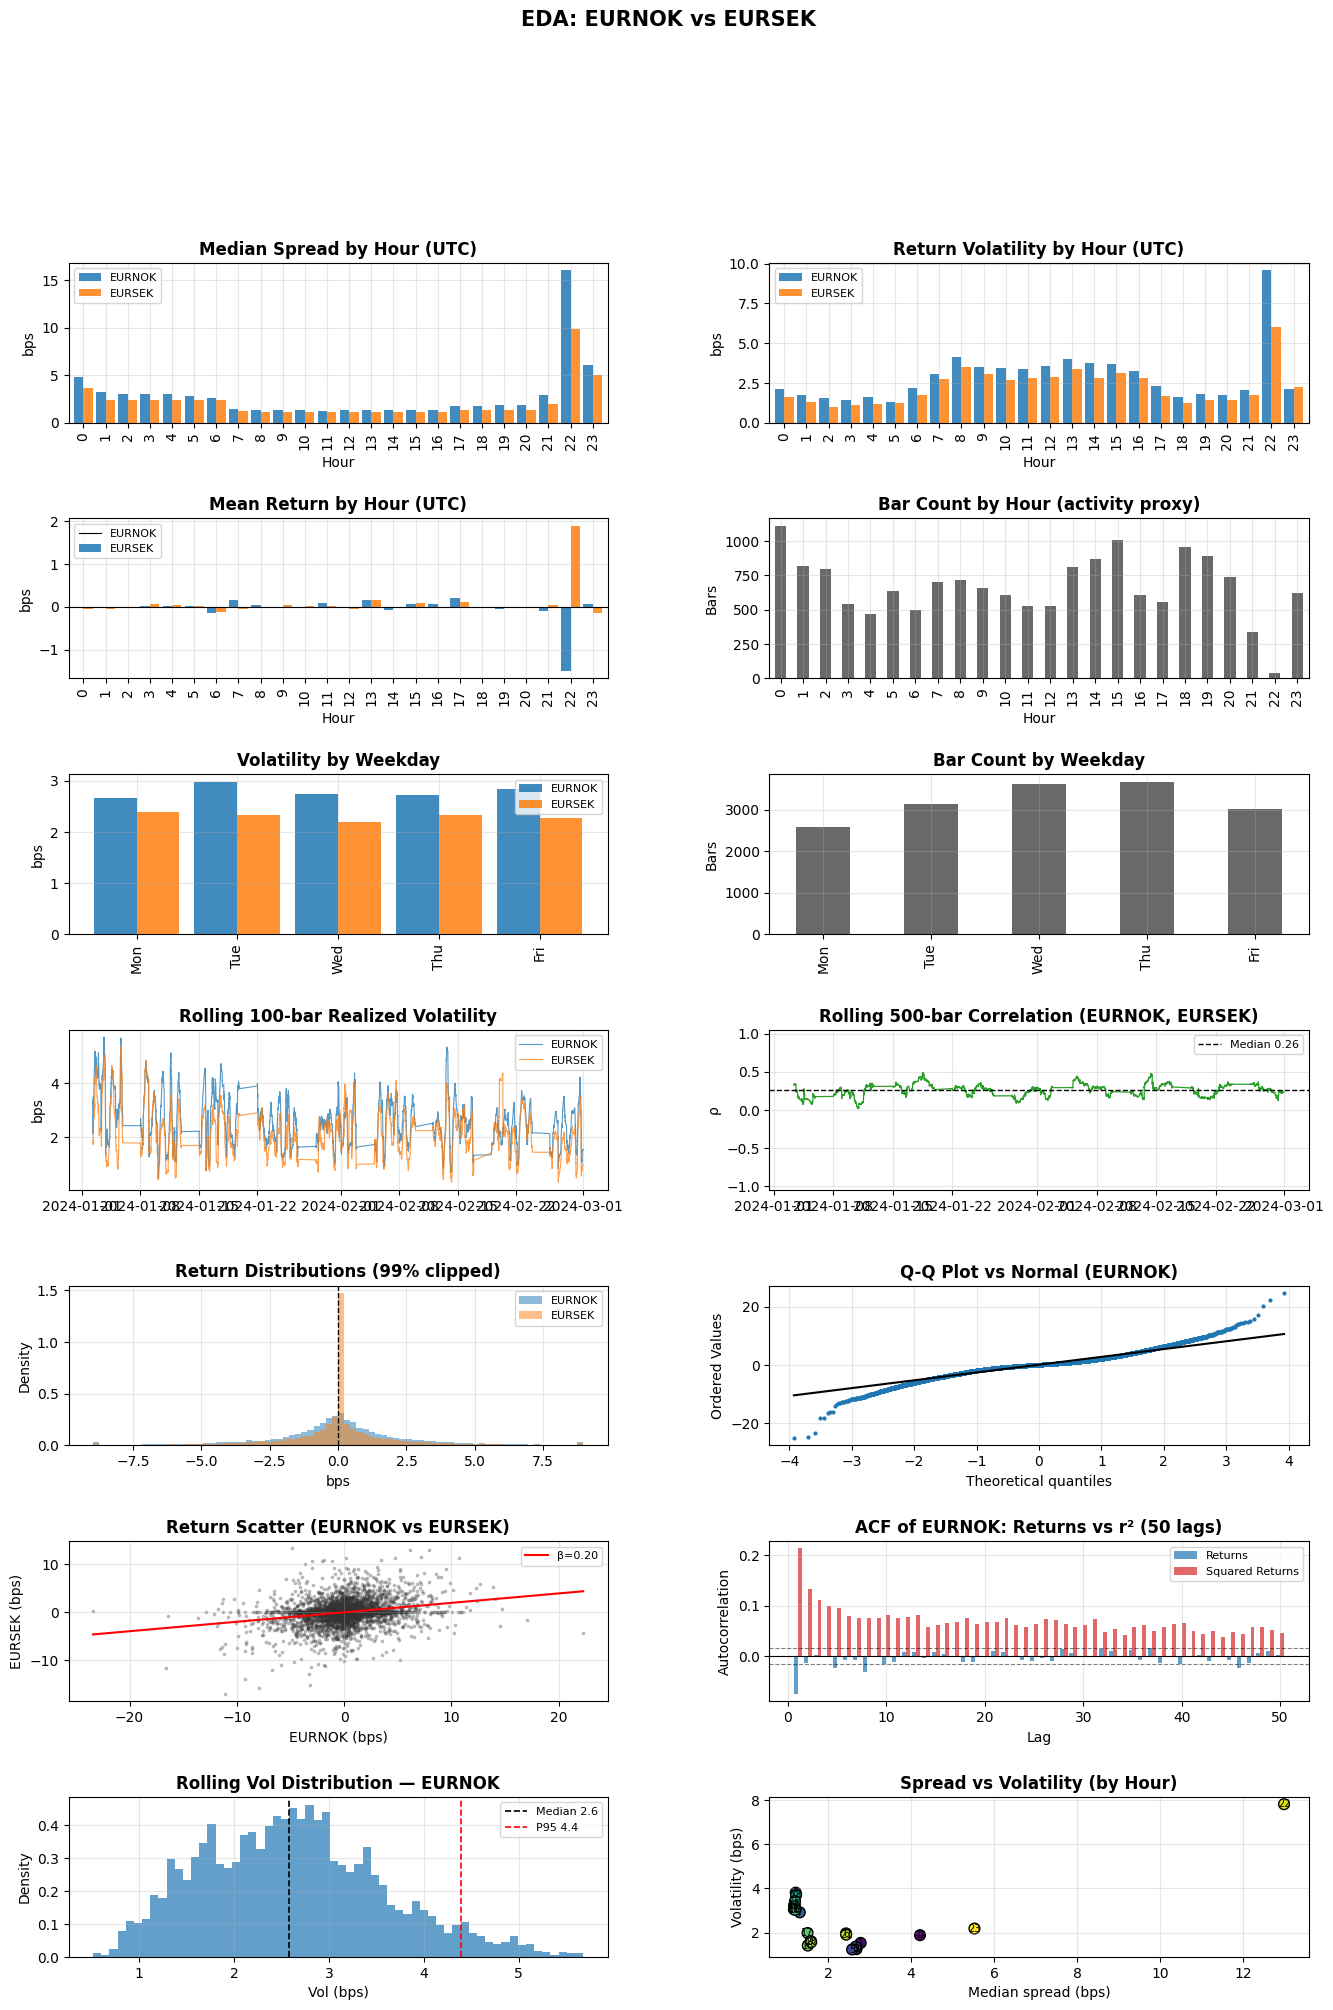

In [6]:
eda_months = ["202401", "202402"]
eda_files = make_files(NAME_A, NAME_B, eda_months)

builder_eda = SPREAD(agg_type='volume', threshold=EDA_THRESHOLD, active_hours=(EDA_START_HOUR, EDA_END_HOUR))
df_raw_eda = builder_eda.build(eda_files)

eda = DESCRIPTIVE(df_raw_eda, NAME_A, NAME_B, save_pdf=SAVE_PLOTS_PDF, pdf_dir=PLOT_OUTDIR, pdf_prefix=PAIR_NAME)
eda.generate_full_eda()

### DATA

In [7]:
months = [
    "202401", "202402", "202403", "202404", "202405", "202406",
    "202407", "202408", "202409", "202410", "202411", "202412",
    "202501", "202502", "202503", "202504", "202505", "202506",
    "202507", "202508", "202509", "202510", "202511", "202512",
]

my_files = make_files(NAME_A, NAME_B, months)

### SPREAD

built 206937 rows
Saved plot PDF: /content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/plots/EURNOK_EURSEK/EURNOK_EURSEK_spread_diagnostics.pdf


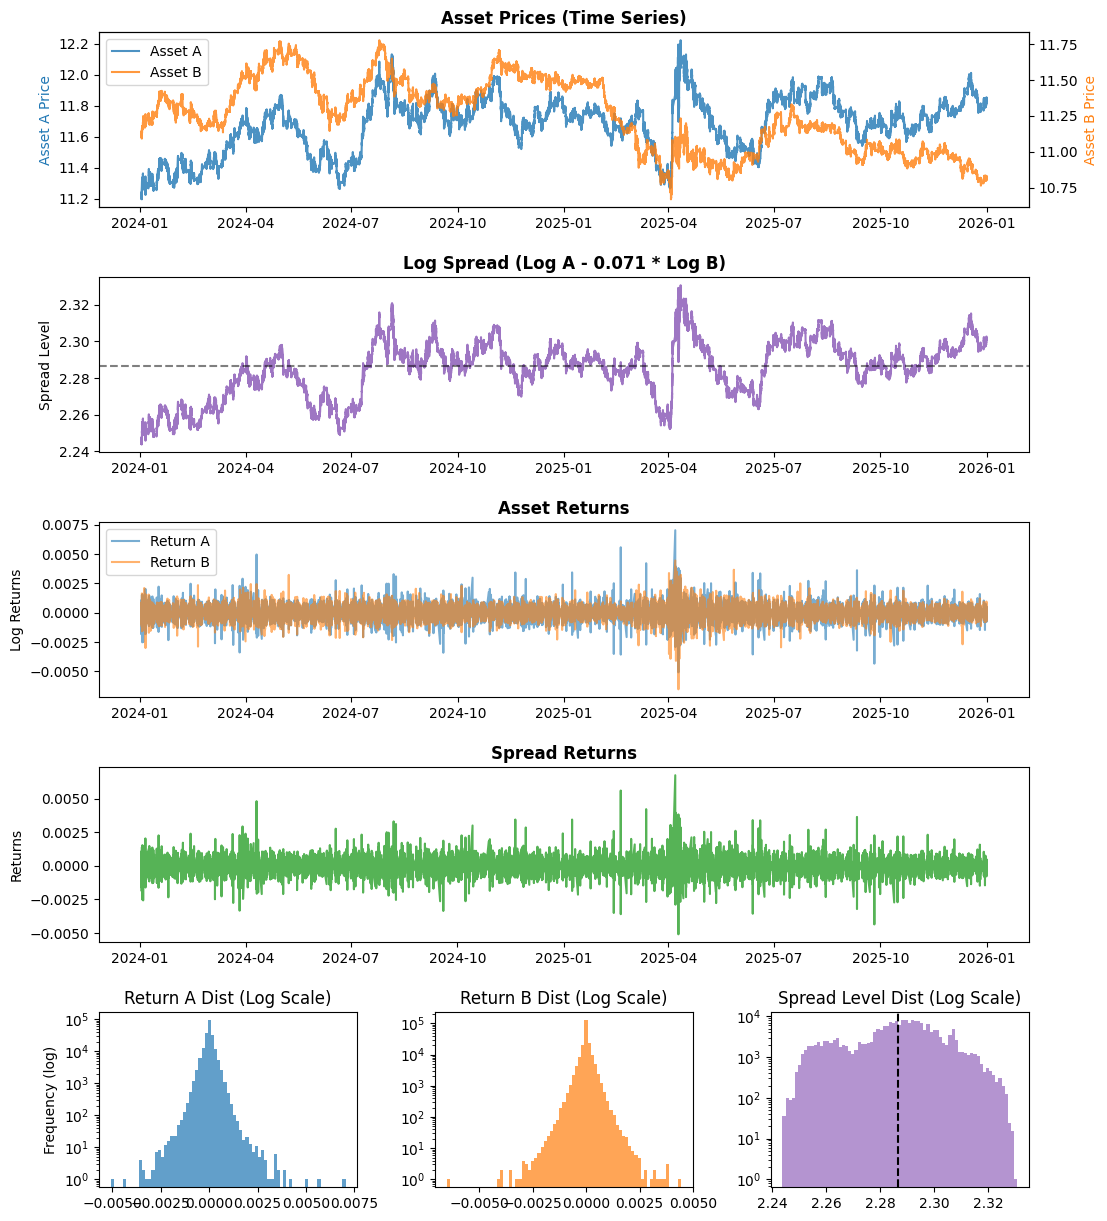

In [8]:
builder = SPREAD(
    agg_type='volume',
    threshold=THRESHOLD,
    active_hours=(START_HOUR, END_HOUR),
    save_pdf=SAVE_PLOTS_PDF,
    pdf_dir=PLOT_OUTDIR,
    pdf_prefix=PAIR_NAME,
)
df = builder.build(my_files)
builder.plot_diagnostics()

### DESCRIPTIVE

In [ ]:
eda = DESCRIPTIVE(df, name_a=NAME_A, name_b=NAME_B)
eda.generate_full_eda()


  DATASET OVERVIEW
Pair:              EURNOK  vs  EURSEK
Bars:              206,937
Period:            2024-01-02 00:10:12.416000+00:00  →  2025-12-31 21:58:59.072000+00:00
Calendar span:     729 days
Trading days:      522
Bars per day:      396.4 (avg)
Hours covered:     [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23)]

  LIQUIDITY PROFILE
Median spread:           A=2.07  B=1.78  bps
P95 spread (tail cost):  A=6.22  B=5.58  bps
Tightest 4h window:      09:00 → 12:00 UTC
Widest   4h window:      20:00 → 23:00 UTC
Round-trip cost (median total): 3.89 bps

  RETURN STATISTICS
        Mean (bps)  Vol (bps)      Skew      Kurt  P5 (bps)  P95 (bps)  Min (bps)  Max (bps)
EURNOK       0.003      2.606     0.178    16.

### SCREENER


=== COINTEGRATION SCREENER ===
Full: p=0.0140 | half-life=4597.2 | β=0.0714

Rolling (2000-bar, step 200, n=1025):
  p<0.05: 13.1% | p<0.10: 21.1%
  half-life: 71.8 (IQR 44–125)
  β: 0.6911 ±0.6648 [-1.4831, 2.6531]


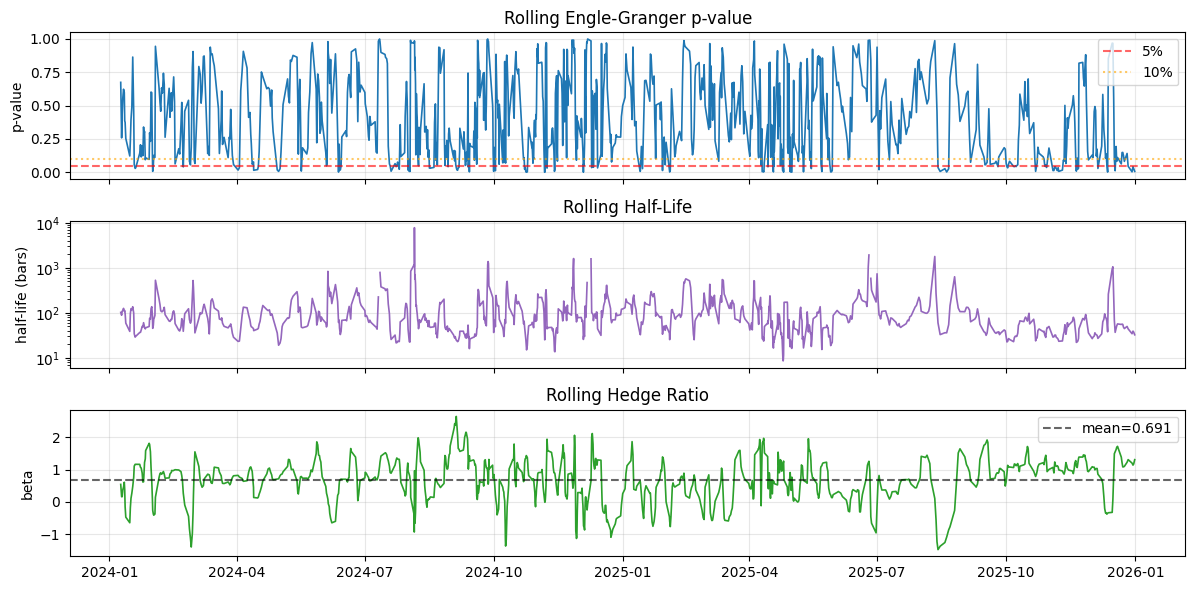

In [ ]:
screener = SCREENER(df['Asset_A'], df['Asset_B'])
p_val, hl = screener.generate_report(rolling_window=ROLLING_WINDOW, rolling_step=ROLLING_STEP)

### RELOAD MODULES

In [ ]:
import importlib
import engine, backtester, tearsheet, wfo

importlib.reload(engine)
importlib.reload(backtester)
importlib.reload(tearsheet)
importlib.reload(wfo)

from engine import ENGINE
from backtester import BACKTESTER
from tearsheet import TEARSHEET
from wfo import WFO

### LIVE TRADING

In [ ]:
live_trading_data, df_params = ENGINE.walk_forward(
    df=df,
    train_days=TRAIN_DAYS,
    coint_window=COINT_WINDOW,
    z_window=Z_WINDOW,
    k_regimes=K_REGIMES,
    winsorize_std=WINSORIZE_STD,
    scaling=SCALING
)

Running Engine | train_days=30 | coint_window=300 | z_window=100
[2024-02-13] Beta: 1.0678 | AR: 0.9778
[2024-02-27] Beta: 0.3689 | AR: 0.9782
[2024-03-12] Beta: 0.6666 | AR: 0.9756
[2024-03-26] Beta: -0.1135 | AR: 0.9756
[2024-04-09] Beta: 0.5233 | AR: 0.9736
[2024-04-23] Beta: 0.7527 | AR: 0.9750
[2024-05-07] Beta: 0.4943 | AR: 0.9729
[2024-05-21] Beta: -0.1956 | AR: 0.9770
[2024-06-04] Beta: -0.1914 | AR: 0.9754
[2024-06-18] Beta: 0.8517 | AR: 0.9793
[2024-07-02] Beta: -0.0695 | AR: 0.9793
[2024-07-16] Beta: 1.1321 | AR: 0.9847
[2024-07-30] Beta: 0.8301 | AR: 0.9842
[2024-08-13] Beta: 2.1673 | AR: 0.9837
[2024-08-27] Beta: 0.0478 | AR: 0.9798
[2024-09-10] Beta: 1.1541 | AR: 0.9790
[2024-09-24] Beta: 0.9911 | AR: 0.9734
[2024-10-08] Beta: 0.6798 | AR: 0.9712
[2024-10-22] Beta: 0.6502 | AR: 0.9738
[2024-11-05] Beta: 0.3662 | AR: 0.9762
[2024-11-19] Beta: 1.2766 | AR: 0.9762
[2024-12-03] Beta: 0.1820 | AR: 0.9752
[2024-12-17] Beta: 0.0147 | AR: 0.9746
[2024-12-31] Beta: 0.8629 | AR: 0.

### BACKTESTER w/ WFO

In [ ]:
from wfo import WFO

wfo = WFO(live_trading_data)
results_wfo = wfo.run_wfo(val_months=VAL_MONTHS, test_months=TEST_MONTHS, n_trials=N_TRIALS)

WFO setup: 3mo train / 1mo test
  Windows:  21
  Trials:   100 per window
  Period:   2024-05-10 → 2025-12-31

  #  Test window                 Best Sharpe   Entry Z   Exit Z   Danger   AR lim     OOS ret
---------------------------------------------------------------------------------------------


WFO windows:   0%|          | 0/21 [00:00<?, ?it/s]

  1  2024-05-10 → 2024-06-07          -4.000      2.50    -0.50     0.65    0.990     -0.0357
  2  2024-06-10 → 2024-07-08          -7.782      2.50    -0.50     0.60    0.990     -0.0276
  3  2024-07-09 → 2024-08-06         -11.373      2.50    -0.50     0.60    0.980     -0.0071
  4  2024-08-07 → 2024-09-04         -12.081      2.50     0.00     0.70    0.980     -0.0206
  5  2024-09-05 → 2024-10-03          -8.387      2.50    -0.10     0.70    0.980     -0.0808
  6  2024-10-04 → 2024-11-01         -14.771      2.40    -0.50     0.90    0.980     -0.0723
  7  2024-11-04 → 2024-12-02         -17.009      2.50    -0.30     0.55    0.980     -0.0786
  8  2024-12-03 → 2024-12-31         -20.624      2.40    -0.50     0.50    0.980     -0.0644
  9  2025-01-01 → 2025-01-29         -20.470      2.50    -0.50     0.50    0.980     -0.0038
 10  2025-01-30 → 2025-02-27         -18.782      2.50    -0.50     0.65    0.980     -0.0234
 11  2025-02-28 → 2025-03-28         -17.192      2.30    -0

### TEARSHEET


                           QUANTITATIVE STRATEGY TEARSHEET                           
Metric                         | Baseline       | AR             | MS_AR          |
-----------------------------------------------------------------------------------

--- RETURN ---
Total Return (bps)             | -13169.17      | -9113.42       | -7381.91       |
Annual Return (bps)            | -8016.73       | -5547.80       | -4493.74       |
Best Month (bps)               | -83.63         | 0.00           | 0.00           |
Worst Month (bps)              | -1903.13       | -1605.71       | -1341.36       |
Positive Months %              | 0.00%          | 0.00%          | 0.00%          |

--- RISK ---
Annual Volatility (bps)        | 778.74         | 603.83         | 502.89         |
Max Drawdown (bps)             | -13203.06      | -9142.38       | -7422.16       |
Max DD Duration (bars)         | 177619         | 177619         | 177666         |
Ulcer Index                    | 7935.84   

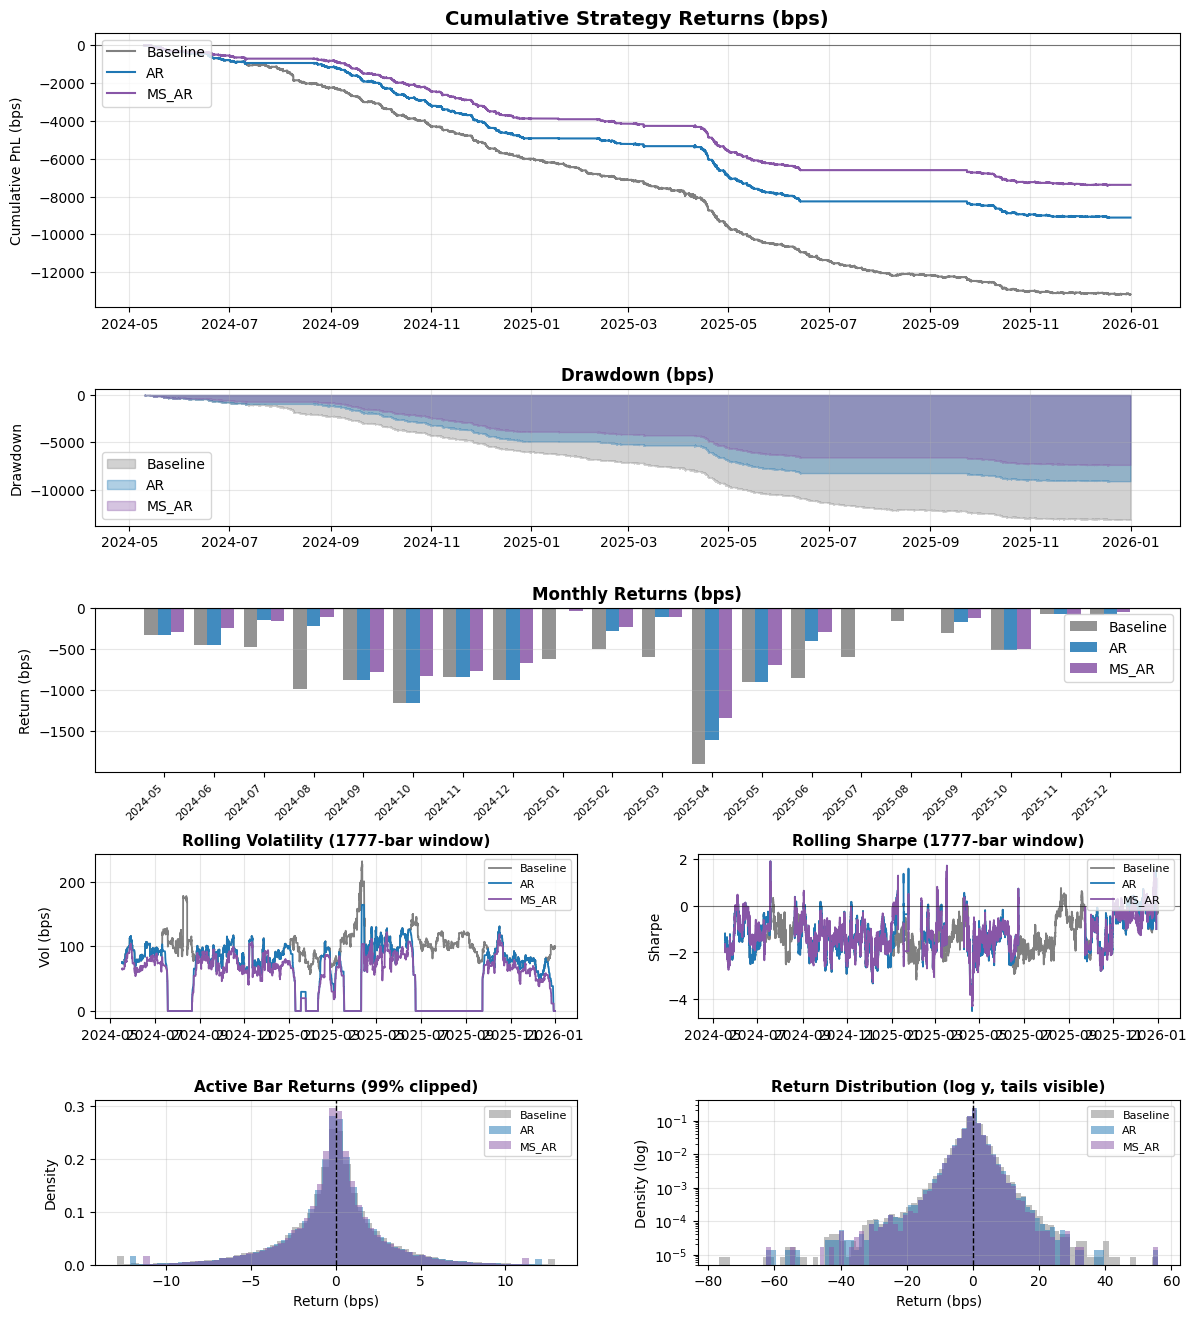

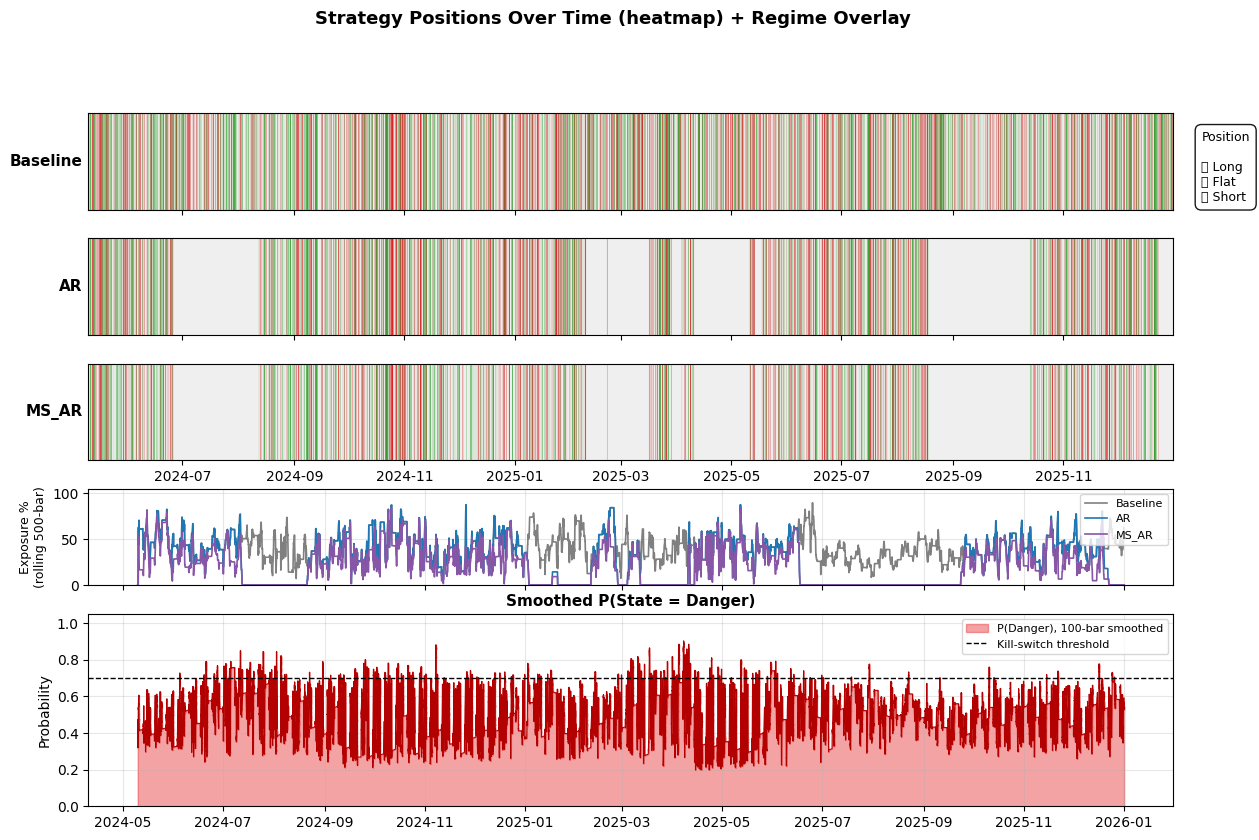

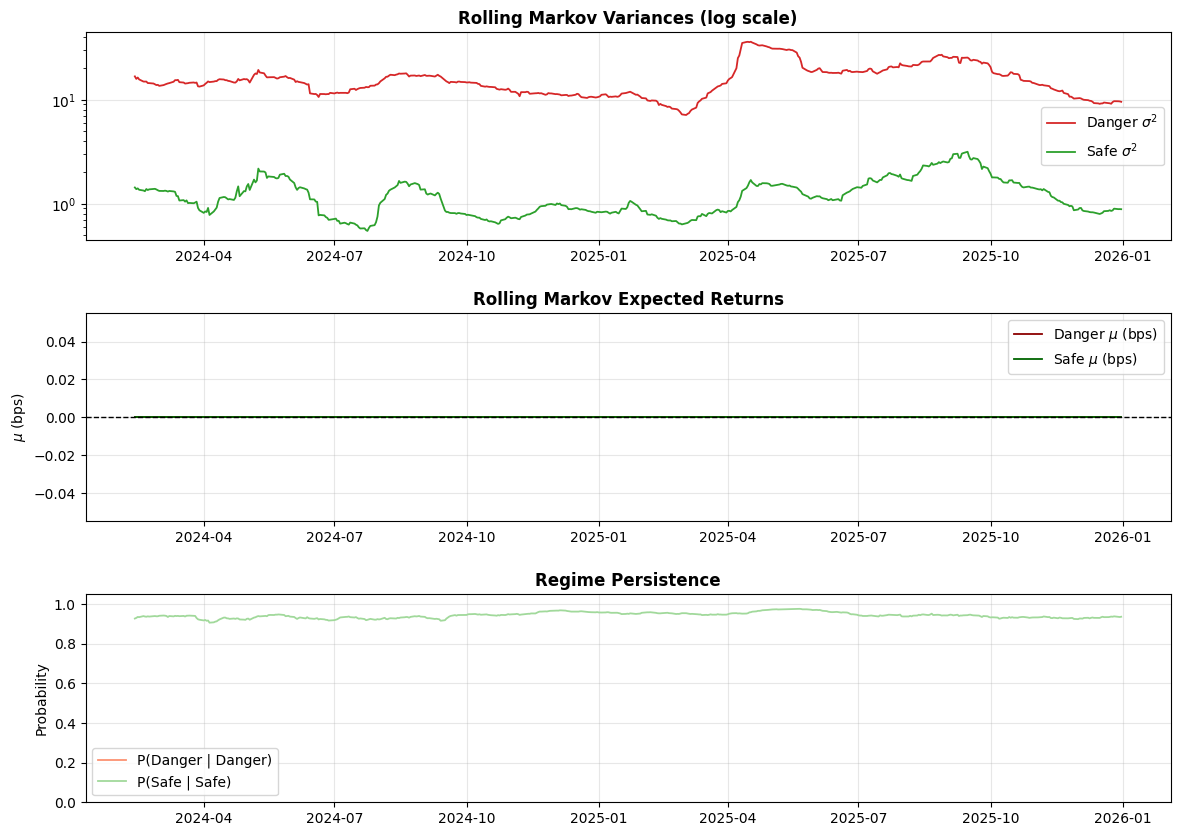

In [ ]:
ts = TEARSHEET(
    results_wfo,
    df_params=df_params,
    save_pdf=SAVE_PLOTS_PDF,
    pdf_dir=PLOT_OUTDIR,
    pdf_prefix=PAIR_NAME,
)
ts.generate_report()
ts.plot_performance()
ts.plot_positions_and_regimes()
ts.plot_markov_dynamics()